In [67]:
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)

device = torch.device("mps" if torch.torch.backends.mps.is_available() else "cpu")
print(device)

mps


# Task 1

### Playground

In [68]:
import gensim.downloader as api

vectors = api.load("glove-wiki-gigaword-50")

print("Vector size:", vectors.vector_size)
print("Vector for 'king':", vectors["king"].shape)

# Cosine similarity
print(vectors.similarity("cat", "dog"))
print(vectors.similarity("cat", "car"))

# Analogy example
result = vectors.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5,
)
print(result)

Vector size: 50
Vector for 'king': (50,)
0.92180055
0.36382526
[('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.759214460849762), ('daughter', 0.7473882436752319), ('elizabeth', 0.7460220456123352)]


In [69]:
print(f"Embedding dimension: {vectors.vector_size}")
print(f"Vocabulary size : {len(vectors)}") 

print("\nCosine Similarities\n")

word_pairs = [
    ("cat", "dog"),
    ("car", "bicycle"),
    ("happy", "sad"),
    ("computer", "keyboard"),
    ("france", "paris"),
]

for w1, w2 in word_pairs:
    sim = vectors.similarity(w1, w2)
    print(f"Similarity {w1} and {w2}: {sim:.4f}")

# Logika: positive=["a", "b"], negative=["c"] to inaczej: a + b - c
analogies = [
    {"pos": ["king", "woman"], "neg": ["man"], "expected": "queen", "comment": "Płeć"},
    {"pos": ["paris", "italy"], "neg": ["france"], "expected": "rome", "comment": "Stolice państw"},
    {"pos": ["swimming", "walk"], "neg": ["swim"], "expected": "walking", "comment": "Czasowniki"},
    {"pos": ["doctor", "teacher"], "neg": ["hospital"], "expected": "school", "comment": "Miejsca pracy"},
    {"pos": ["bird", "fish"], "neg": ["fly"], "expected": "swim", "comment": "Sposób poruszania sie"}
]

table_data = []

for item in analogies:
    # Pobieramy 5 najbliższych sąsiadów
    top_results = vectors.most_similar(positive=item["pos"], negative=item["neg"], topn=5)
    top_word = top_results[0][0]
    
    success = "yes" if top_word == item["expected"] else "no"
    
    equation = f"{item['pos'][0]} - {item['neg'][0]} + {item['pos'][1]}"
    
    table_data.append({
        "Analogy": equation,
        "Expected answer": item["expected"],
        "Top result": top_word,
        "Was it reasonable?": success,
        "Short comment": item["comment"],
        "Top 5": [w for w, _ in top_results]
    })

df_analogies = pd.DataFrame(table_data)
display(df_analogies.drop(columns=["Top 5"]))

print(table_data[-1]["Top 5"])

Embedding dimension: 50
Vocabulary size : 400000

Cosine Similarities

Similarity cat and dog: 0.9218
Similarity car and bicycle: 0.7560
Similarity happy and sad: 0.6891
Similarity computer and keyboard: 0.5768
Similarity france and paris: 0.8025


,Analogy,Expected answer,Top result,Was it reasonable?,Short comment
0,king - man + woman,queen,queen,yes,Płeć
1,paris - france + italy,rome,rome,yes,Stolice państw
2,swimming - swim + walk,walking,walking,yes,Czasowniki
3,doctor - hospital + teacher,school,author,no,Miejsca pracy
4,bird - fly + fish,swim,animal,no,Sposób poruszania sie


['animal', 'fauna', 'species', 'shellfish', 'edible']


3 i 4 nie dały rady, są może trochę bardziej złożone, ale wciąż nie jakieś wymyślne, pewnie nie tak bardzo popularne

* what a word embedding represents
    - jest to interpretacja słowa za pomocą wielu cech, niekoniecznie nam znaych, mają po prostu dobrze rozróżniać słowa
* why cosine similarity is useful for word vectors
    - ma to geometryczną interpretacje z przestrzeni euklidesowych, jest to długość rzutu jednego wektora na drugi, można o tym myśleć, właśnie "jaka cześć jednego składa się na drugi"
* why vector arithmetic can sometimes encode semantic relationships
    - przy "dobrym" embeddingu tego byśmy oczekiwali, jest to naturalne też dlatego, że iloczyn skalarny (cosine similarity, bez normalizacji) to operacja dwuliniowa, podobieństwa mają rozkładać się odpwiednio na składowe
* why it does not always work
    - świat nie jest idealny, a nie jest to zapewno główny cel treningu

# Task 2

In [70]:
import torch.nn.functional as F

corpus = ["the", "cat", "sat", "on", "the", "mat"]
window_size = 1

vocab = sorted(list(set(corpus)))
word_to_idx = {word: i for i, word in enumerate(vocab)}
V = len(vocab)
d = 3 

print(f"Słownik: {word_to_idx}\n")

skipgram_pairs = []
for i, center_word in enumerate(corpus):
    for j in range(max(0, i - window_size), min(len(corpus), i + window_size + 1)):
        if i != j:
            outside_word = corpus[j]
            skipgram_pairs.append((center_word, outside_word))

print("Wszystkie pary (skip-gram):", skipgram_pairs, "\n")

Słownik: {'cat': 0, 'mat': 1, 'on': 2, 'sat': 3, 'the': 4}

Wszystkie pary (skip-gram): [('the', 'cat'), ('cat', 'the'), ('cat', 'sat'), ('sat', 'cat'), ('sat', 'on'), ('on', 'sat'), ('on', 'the'), ('the', 'on'), ('the', 'mat'), ('mat', 'the')] 



In [71]:
# Inicjalizujemy losowe macierze osadzeń (input i output)
input_embeddings = torch.randn(V, d, requires_grad=True)  # W_in    (wektory dla słów centralnych)
output_embeddings = torch.randn(V, d, requires_grad=True) # W_out   (wektory dla słów kontekstowych)

# Ręczne obliczenia
selected_pair = skipgram_pairs[2] # ('cat', 'sat')
center_word, target_outside_word = selected_pair
center_idx = word_to_idx[center_word]
target_idx = word_to_idx[target_outside_word]

print(f"center='{center_word}', outside='{target_outside_word}'")

# a) Wektor słowa centralnego (v_c)
v_c = input_embeddings[center_idx]
print(f"Wektor v_c (center '{center_word}'): {v_c.detach().numpy()}")

# b)  Wyniki (scores/logits) - iloczyn skalarny v_c z KAŻDYM wektorem z output_embeddings
# output_embeddings ma kształt (5, 3), v_c ma kształt (3,)
# (5, 3) @ (3,) -> (5,)
scores = torch.matmul(output_embeddings, v_c)
print(f"Scores (s_k) dla całego słownika: {scores.detach().numpy()}")

# c) Softmax - przekształcenie wyników na prawdopodobieństwa
probs = torch.softmax(scores, dim=0)
print(f"Probabilities po Softmax: {probs.detach().numpy()}")

# d) Obliczenie straty (Negative Log-Likelihood) dla docelowego słowa kontekstowego
prob_target = probs[target_idx]
manual_loss = -torch.log(prob_target)
print(f"Ręcznie policzony Loss tzn -log(P({target_outside_word} | {center_word})) : {manual_loss.item():.4f}")

# Weryfikacja za pomocą PyTorchowego F.cross_entropy
# F.cross_entropy spodziewa się (logits, target_index) i sama robi log-softmax pod maską
pytorch_loss = F.cross_entropy(scores.unsqueeze(0), torch.tensor([target_idx]))
print(f"Loss policzony przez PyTorch: {pytorch_loss.item():.4f}")
print("Czy wyniki są równe? (bliskie?)", torch.allclose(manual_loss, pytorch_loss))

# tabelka dla wybranej pary
table_data = []
for i, word in enumerate(vocab):
    target_val = 1 if i == target_idx else 0
    table_data.append({
        "Vocabulary word": word,
        "Score (Logit)": round(scores[i].item(), 4),
        "Softmax probability": round(probs[i].item(), 4),
        "Target": target_val
    })

print("\nTabela dla wybranej pary:")
df_pair = pd.DataFrame(table_data)
display(df_pair)

# Średnia strata dla wszystkich par
total_loss = 0
for c_word, o_word in skipgram_pairs:
    c_idx = word_to_idx[c_word]
    o_idx = word_to_idx[o_word]
    
    v_c_temp = input_embeddings[c_idx]
    scores_temp = torch.matmul(output_embeddings, v_c_temp)
    loss_temp = F.cross_entropy(scores_temp.unsqueeze(0), torch.tensor([o_idx]))
    total_loss += loss_temp

avg_loss = total_loss / len(skipgram_pairs)
print(f"\nŚredni Loss dla wszystkich ({len(skipgram_pairs)}) par: {avg_loss.item():.4f}")

center='cat', outside='sat'
Wektor v_c (center 'cat'): [0.33669037 0.1288094  0.23446237]
Scores (s_k) dla całego słownika: [ 0.68444353 -0.03741619  0.37524983  0.22457656  0.03672573]
Probabilities po Softmax: [0.29634085 0.14397658 0.21752562 0.18710002 0.15505695]
Ręcznie policzony Loss tzn -log(P(sat | cat)) : 1.6761
Loss policzony przez PyTorch: 1.6761
Czy wyniki są równe? (bliskie?) True

Tabela dla wybranej pary:


,Vocabulary word,Score (Logit),Softmax probability,Target
0,cat,0.6844,0.2963,0
1,mat,-0.0374,0.1440,0
2,on,0.3752,0.2175,0
3,sat,0.2246,0.1871,1
4,the,0.0367,0.1551,0



Średni Loss dla wszystkich (10) par: 1.9084


* what the center word and outside word mean
    - słowo centralne to klucz, na podstawie którego model na przewidzieć outside_words
* why the denominator of the softmax uses all vocabulary words
    - model ma za zadanie utworzyć rozkład prawdopodobieństwa na wszystkich możlowych słowach ze słownika, takze wyniki musi być unormlwany przez wszystkie możliwości
* why this is expensive for large vocabularies
    - zgrubsza koszt wyliczenia tabeli podomieństw to O(V^2 * D) gdzie V to rozmiar słownika a D to wielkość embeddingu, także sporo
* why negative sampling is often used in practice
    - to przekształca problem w klasyfikacje binarną (bliżej takiej), upraszcza trening
* what PyTorch autograd would compute if requires_grad=True
    - klaycznie policzyłby dla nas gradienty dla input_embeddings

# Task 3

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
import gensim.downloader as api

texts = [
    "team wins the football match",
    "government passes new law",
    "new smartphone has fast processor",
    "stock market rises today",
    "player scores a goal",
    "election results are announced",
    "software update improves performance",
    "company reports higher profit",
]

labels = [0, 1, 2, 3, 0, 1, 2, 3]
class_names = ["sports", "politics", "technology", "business"]

def tokenize(text):
    return text.lower().split()

special_tokens = ["<pad>", "<unk>"]
all_tokens = []
for text in texts:
    all_tokens.extend(tokenize(text))

# Budujemy unikalny słownik
vocab = special_tokens + sorted(set(all_tokens))
word_to_idx = {word: i for i, word in enumerate(vocab)}

pad_idx = word_to_idx["<pad>"]
unk_idx = word_to_idx["<unk>"]

# Kodowanie tekstu (padding / truncation)
max_len = 8

def encode(text, max_len=max_len):
    ids = [word_to_idx.get(tok, unk_idx) for tok in tokenize(text)]
    ids = ids[:max_len]
    ids = ids + [pad_idx] * (max_len - len(ids))
    return ids

X = torch.tensor([encode(text) for text in texts], dtype=torch.long)
y = torch.tensor(labels, dtype=torch.long)

In [73]:
print("Przygotowywanie wektorów GloVe...")
vectors = api.load("glove-wiki-gigaword-50")
embedding_dim = 50

# Inicjalizujemy macierz losowymi liczbami
pretrained_weights = torch.randn(len(vocab), embedding_dim) * 0.01

# Jeśli znamy słowo z GloVe, nadpisujemy wektor losowy wektorem z GloVe
for i, word in enumerate(vocab):
    if word in vectors:
        pretrained_weights[i] = torch.tensor(vectors[word])

Przygotowywanie wektorów GloVe...


In [74]:
class ManualRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, padding_idx=0):
        super().__init__()
        
        # Inicjalizacja Embeddingu
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.hidden_dim = hidden_dim

        # W_xh: Wagi transformujące wejście x_t
        self.W_xh = nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.01)
        # W_hh: Wagi transformujące poprzedni stan ukryty h_{t-1}
        self.W_hh = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01)
        # b_h: Bias dla stanu ukrytego
        self.b_h = nn.Parameter(torch.zeros(hidden_dim))

        # Ostatnia warstwa klasyfikatora (mapuje ukryty stan na klasy)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)
        # embedded shape: (batch_size, seq_len, embedding_dim)

        batch_size, seq_len, _ = embedded.shape
        
        # Wektor początkowy pamięci (same zera na starcie)
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        # Przebieg czasu
        for t in range(seq_len):
            x_t = embedded[:, t, :]
            # Aktualizacja stanu: h_t = tanh(x_t * W_xh + h_prev * W_hh + b_h)
            h = torch.tanh(torch.matmul(x_t, self.W_xh) + torch.matmul(h, self.W_hh) + self.b_h)

        # Logity przewidujemy bazując tylko na stanie z ostatniego kroku
        logits = self.classifier(h)
        return logits

In [75]:
hidden_dim = 64
num_classes = 4

model = ManualRNNClassifier(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_classes=num_classes,
    padding_idx=pad_idx,
).to(device)

# przygotowane wagi z GloVe
model.embedding.weight.data.copy_(pretrained_weights)

# kształty tensorów
batch = X.to(device)
y_tensor = y.to(device)

print("\nShapes:")
print(f"1. Input batch shape: {batch.shape}")
print(f"2. Embedded batch shape: {model.embedding(batch).shape}")
print(f"3. Hidden state shape: {torch.zeros(batch.shape[0], hidden_dim).shape}")
logits = model(batch)
print(f"4. Logits shape: {logits.shape}\n")


Shapes:
1. Input batch shape: torch.Size([8, 8])
2. Embedded batch shape: torch.Size([8, 8, 50])
3. Hidden state shape: torch.Size([8, 64])
4. Logits shape: torch.Size([8, 4])



In [76]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 20

print("\nTRAINING") 

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    preds = model(batch)
    loss = criterion(preds, y_tensor)
    
    loss.backward()
    optimizer.step()

    # nie mamy tutaj żadnego inne zboiru danych, wiec sprawdzamy po porstu accuracy na train    
    acc = (preds.argmax(dim=1) == y_tensor).float().mean()
    
    print(f"Epoch {epoch+1:02d}/{epochs}| Loss: {loss.item():.4f} | Accuracy: {acc.item():.4f}")


TRAINING
Epoch 01/20| Loss: 1.3868 | Accuracy: 0.2500
Epoch 02/20| Loss: 1.3859 | Accuracy: 0.2500
Epoch 03/20| Loss: 1.3748 | Accuracy: 0.3750
Epoch 04/20| Loss: 1.3131 | Accuracy: 0.6250
Epoch 05/20| Loss: 1.1284 | Accuracy: 0.6250
Epoch 06/20| Loss: 1.0693 | Accuracy: 0.5000
Epoch 07/20| Loss: 0.8320 | Accuracy: 0.7500
Epoch 08/20| Loss: 0.8329 | Accuracy: 0.8750
Epoch 09/20| Loss: 0.7423 | Accuracy: 0.7500
Epoch 10/20| Loss: 0.5425 | Accuracy: 1.0000
Epoch 11/20| Loss: 0.3251 | Accuracy: 1.0000
Epoch 12/20| Loss: 0.1785 | Accuracy: 1.0000
Epoch 13/20| Loss: 0.1031 | Accuracy: 1.0000
Epoch 14/20| Loss: 0.0614 | Accuracy: 1.0000
Epoch 15/20| Loss: 0.0408 | Accuracy: 1.0000
Epoch 16/20| Loss: 0.0274 | Accuracy: 1.0000
Epoch 17/20| Loss: 0.0184 | Accuracy: 1.0000
Epoch 18/20| Loss: 0.0129 | Accuracy: 1.0000
Epoch 19/20| Loss: 0.0085 | Accuracy: 1.0000
Epoch 20/20| Loss: 0.0065 | Accuracy: 1.0000


* why the embedding layer converts token IDs into vectors
    - jest to pewien encoding pozycyjny, nie jest to najlepsze podjście, ale pozwala lepiej operować w strukturze tekstu
* how the hidden state changes over time
    - w każdym kroku czasu h_t jest napisywane, bierze ono pod uwagę poprzednią pamieć h_{t-1} oraz akutalne słowo x_t (+ wagi modelu i tanh) 
        dokładnie to h_t = tanh(x_t * W_xh + h_prev * W_hh + b_h)
* why the final hidden state can be used for classification
    - h_t zawiera inforamcje z całej sekwencji, naturalnie zostaje do tego użyty
* what PyTorch autograd does in this manually implemented RNN
    - Autograd śledzi każdą operacje, a na loss.backward() automatycznie wylicza gradienty wstecz wzdłuż osi czasu (Backpropagation Through Time)
* one limitation of vanilla RNNs
    - poprzez regułe łańucha dostaje znikające bądź eksplodujące gradienty (geometryczne przemnażanie w każdej iteracji)

# Task 4

In [77]:
from torch.utils.data import TensorDataset, DataLoader

texts_task4 = [
    "team wins the football match",           # 0: sports
    "government passes new law",              # 1: politics
    "new smartphone has fast processor",      # 2: tech
    "stock market rises today",               # 3: business
    "player scores a goal",                   # 0: sports
    "election results are announced",         # 1: politics
    "software update improves performance",   # 2: tech
    "company reports higher profit",          # 3: business
    "championship finals are tomorrow",       # 0: sports
    "senate debates the new bill",            # 1: politics
    "tech giant releases new laptop",         # 2: tech
    "inflation rates are going down",         # 3: business
    "coach trains the basketball squad",      # 0: sports
    "mayor gives a speech",                   # 1: politics
    "new app uses artificial intelligence",   # 2: tech
    "investors buy more shares"               # 3: business
]
labels_task4 = [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]

In [78]:
all_tokens_t4 = []
for text in texts_task4:
    all_tokens_t4.extend(tokenize(text))

vocab_t4 = special_tokens + sorted(set(all_tokens_t4))
word_to_idx_t4 = {word: i for i, word in enumerate(vocab_t4)}
pad_idx_t4 = word_to_idx_t4["<pad>"]
unk_idx_t4 = word_to_idx_t4["<unk>"]

def encode_t4(text, max_len=8):
    ids = [word_to_idx_t4.get(tok, unk_idx_t4) for tok in tokenize(text)]
    ids = ids[:max_len]
    ids = ids + [pad_idx_t4] * (max_len - len(ids))
    return ids

X_t4 = torch.tensor([encode_t4(text) for text in texts_task4], dtype=torch.long)
y_t4 = torch.tensor(labels_task4, dtype=torch.long)

# Nowe wagi GloVe dla nowego słownika
pretrained_weights_t4 = torch.randn(len(vocab_t4), 50) * 0.01
for i, word in enumerate(vocab_t4):
    if word in vectors:
        pretrained_weights_t4[i] = torch.tensor(vectors[word])

In [79]:
# Podział: 12 na trening, 4 na walidację
X_train, y_train = X_t4[:12], y_t4[:12]
X_val, y_val = X_t4[12:], y_t4[12:]

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

In [80]:
EPOCHS = 30 

def run_experiment(model_type, freeze_embeds):
    model = RecurrentClassifier(
        vocab_size=len(vocab_t4),
        embedding_dim=50,
        hidden_dim=128,
        num_classes=4, 
        model_type=model_type,
        padding_idx=pad_idx_t4,
        pretrained_embedding_matrix=pretrained_weights_t4, # Podpinamy zaktualizowane GloVe!
        freeze_embeddings=freeze_embeds
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    val_acc_history = []
    start_time = time.time()
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_X.size(0)
        train_loss /= len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                logits = model(batch_X)
                loss = criterion(logits, batch_y)
                val_loss += loss.item() * batch_X.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == batch_y).sum().item()
                
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        val_acc_history.append(val_acc)
        
    return {
        "Model": f"{model_type.upper()} ({'Frozen' if freeze_embeds else 'Trainable'})",
        "Trainable parameters": count_trainable_parameters(model),
        "Final train loss": round(train_loss, 4),
        "Final val loss": round(val_loss, 4),
        "Final val accuracy": round(val_acc, 4),
        "Training time (s)": round(time.time() - start_time, 4),
        "val_acc_history": val_acc_history
    }

Rozpoczynam eksperymenty...


,Model,Trainable parameters,Final train loss,Final val loss,Final val accuracy,Training time (s)
0,LSTM (Frozen),92676,0.1228,0.1556,1.0,0.1300
1,LSTM (Trainable),95876,0.1635,0.1562,1.0,0.1542
2,GRU (Frozen),69636,0.1289,0.1366,1.0,0.2446
3,GRU (Trainable),72836,0.0793,0.1027,1.0,0.2548


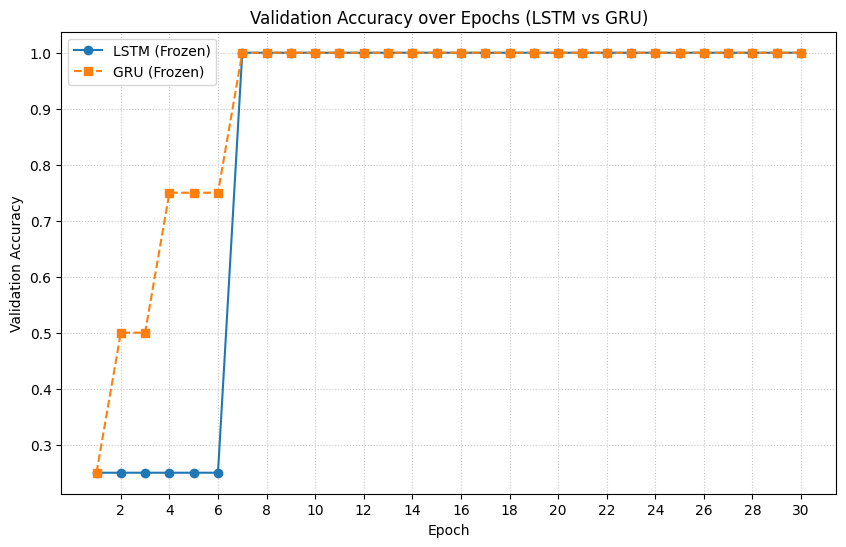

In [81]:
print("Rozpoczynam eksperymenty...")
results = [
    run_experiment("lstm", freeze_embeds=True),
    run_experiment("lstm", freeze_embeds=False),
    run_experiment("gru", freeze_embeds=True),
    run_experiment("gru", freeze_embeds=False)
]

df_results = pd.DataFrame(results).drop(columns=["val_acc_history"])
display(df_results)

plt.figure(figsize=(10, 6))
epochs_range = range(1, EPOCHS + 1)
plt.plot(epochs_range, results[0]["val_acc_history"], marker='o', label='LSTM (Frozen)', linestyle='-')
plt.plot(epochs_range, results[2]["val_acc_history"], marker='s', label='GRU (Frozen)', linestyle='--')
plt.title('Validation Accuracy over Epochs (LSTM vs GRU)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(range(2, EPOCHS + 1, 2))
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

* Which model achieved better validation accuracy?
    - dataset jest tak mały, że oczywsitym jest tutaj to że oba osiągną 100% (overfitting?)
* Which model had fewer parameters?
    - gru, sporo mniej
* Which model trained faster?
    - gru, mniej parametrów, prostra architektura, mały dateset
* Did the result match the theory that GRU usually has fewer parameters than LSTM?
    - tak, taki wynika daje metoda count_parameters ze starter code

## Final Questions

1. What is the difference between one-hot vectors and dense word embeddings?
    - one-hot zajmują znacznie wiecej pamięci oraz tracą geometryczną interpertacje, nie ma tam naturalnej metryki euklidesowej, są to wierzchołki hiperkostki
2. What does Word2Vec try to predict?
    - zalezy od wariantów, czasem ze słowa pierwszego chcemy te otaczające czasem odwrotnie
3. Why is full softmax expensive for large vocabularies?
    - potrzebujemy obliczyć iloczyny skalarne każdy z kazdym, co koszstuje nas kwdaratowy czas
4. What is the hidden state in an RNN?
    - to wektor pełniący role pamięci modelu, raczej krótkotrwałej, akutalizuję ją akutalnym kontekstem
5. Why do LSTM and GRU usually work better than vanilla RNNs on longer sequences?
    - rozwiązuje problem znikającego gradientu. LSTM i GRU wykorzystują mechanizmy "bramek", które potrafią selektywnie przepuszczać ważne informacje wzdłuż osi czasu
6. What is the main architectural difference between LSTM and GRU?
    - LSTM jest bardziej złożony, posiada 3 bramki (Input, Output, Forget) i rozdziela pamięć na dwa strumienie: stan ukryty (Hidden State) oraz długoterminowy stan komórki (Cell State).
    - GRU posiada tylko 2 bramki (Update, Reset) i operuje na pojedynczym stanie ukrytym 